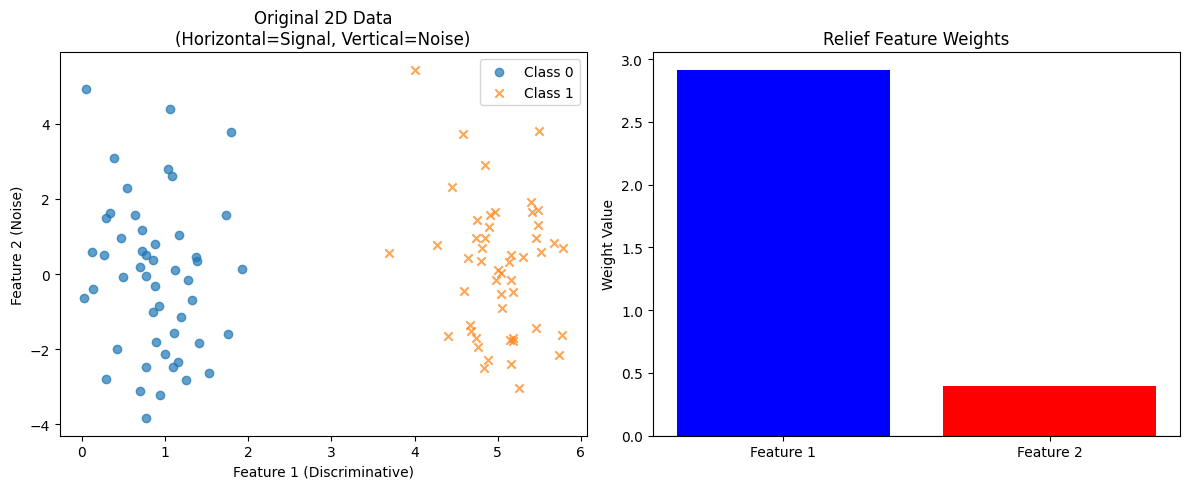

計算得出的特徵權重: 特徵1=2.9099, 特徵2=0.3956


In [23]:
import numpy as np
import matplotlib.pyplot as plt

def relief_algorithm(X, y):
    n_samples, n_features = X.shape
    weights = np.zeros(n_features)

    for i in range(n_samples):
        target_x = X[i]
        target_y = y[i]

        # 尋找最近同類 (Nearest Hit)
        hit_idx = np.where((y == target_y) & (np.arange(n_samples) != i))[0]
        dist_hit = np.linalg.norm(X[hit_idx] - target_x, axis=1)
        x_hit = X[hit_idx[np.argmin(dist_hit)]]

        # 尋找最近異類 (Nearest Miss)
        miss_idx = np.where(y != target_y)[0]
        dist_miss = np.linalg.norm(X[miss_idx] - target_x, axis=1)
        x_miss = X[miss_idx[np.argmin(dist_miss)]]

        # 根據公式更新權重: w = w + |x - x_miss| - |x - x_hit|
        weights += np.abs(target_x - x_miss) - np.abs(target_x - x_hit)

    return weights / n_samples

# 1. 產生模擬數據 (2維)
np.random.seed(42)
n_points = 100
# 特徵 0 是有意義的 (類別 0 在 1 附近, 類別 1 在 5 附近)
f0_class0 = np.random.normal(1, 0.5, n_points // 2)
f0_class1 = np.random.normal(5, 0.5, n_points // 2)
# 特徵 1 是雜訊 (兩類都在 0 附近，完全重疊)
f1_noise = np.random.normal(0, 2, n_points)

X = np.zeros((n_points, 2))
X[:n_points//2, 0] = f0_class0
X[n_points//2:, 0] = f0_class1 #第0維度有用的訊號
X[:, 1] = f1_noise # 第一維度是雜訊
y = np.array([0]*(n_points//2) + [1]*(n_points//2))

# 2. 執行 Relief
weights = relief_algorithm(X, y)

# 3. 繪圖
plt.figure(figsize=(12, 5))

# 圖一：原始數據分佈
plt.subplot(1, 2, 1)
plt.scatter(X[y==0, 0], X[y==0, 1], label='Class 0', alpha=0.7)
plt.scatter(X[y==1, 0], X[y==1, 1], label='Class 1', alpha=0.7, marker='x')
plt.title("Original 2D Data\n(Horizontal=Signal, Vertical=Noise)")
plt.xlabel("Feature 1 (Discriminative)")
plt.ylabel("Feature 2 (Noise)")
plt.legend()

# 圖二：特徵權重
plt.subplot(1, 2, 2)
plt.bar(['Feature 1', 'Feature 2'], weights, color=['blue', 'red'])
plt.title("Relief Feature Weights")
plt.ylabel("Weight Value")
plt.axhline(0, color='black', lw=0.8)

plt.tight_layout()
plt.show()

print(f"計算得出的特徵權重: 特徵1={weights[0]:.4f}, 特徵2={weights[1]:.4f}")